# Project - Airline AI Assistant

We'll now bring together what we've learned to make an AI Customer Support assistant for an Airline

In [1]:
# imports

import os
import json
from dotenv import load_dotenv
from openai import OpenAI
import gradio as gr
import sqlite3

In [18]:
# Initialization

load_dotenv(override=True)

google_api_key = os.getenv('GOOGLE_API_KEY')
groq_api_key = os.getenv('GROQ_API_KEY')

if not google_api_key:
    raise ValueError("GOOGLE_API_KEY environment variable is not set.")
if not groq_api_key:
    raise ValueError("GROQ_API_KEY environment variable is not set.")

openai = OpenAI()

gemini_url = "https://generativelanguage.googleapis.com/v1beta/openai/"
groq_url = "https://api.groq.com/openai/v1"

gemini = OpenAI(api_key=google_api_key, base_url=gemini_url)
groq = OpenAI(api_key=groq_api_key, base_url=groq_url)

MODEL_groq = "llama-3.3-70b-versatile" # groq
MODEL_gemini ="gemini-2.5-flash"  # gemini

DB = "prices.db"

In [34]:
system_message = "you are a helpful assistant for an Airline called FlightAI." \
"Give short courteous answers no more than 1 sentennce. Always be accurate. " \
"If u dont know answer say so and dont make up an answer. " 

In [5]:
def get_ticket_price(city):
    print(f"DATABASE TOOL CALLED: Getting price for {city}", flush=True)
    with sqlite3.connect(DB) as conn:
        cursor = conn.cursor()
        cursor.execute('SELECT price FROM prices WHERE city = ?', (city.lower(),))
        result = cursor.fetchone()
        return f"Ticket price to {city} is ${result[0]}" if result else "No price data available for this city"

In [6]:
get_ticket_price("Paris")

DATABASE TOOL CALLED: Getting price for Paris


'Ticket price to Paris is $899.0'

In [7]:
price_function = {
    "name": "get_ticket_price",
    "description": "Get the price of a return ticket to the destination city.",
    "parameters": {
        "type": "object",
        "properties": {
            "destination_city": {
                "type": "string",
                "description": "The city that the customer wants to travel to",
            },
        },
        "required": ["destination_city"],
        "additionalProperties": False
    }
}
tools = [{"type": "function", "function": price_function}]
tools

[{'type': 'function',
  'function': {'name': 'get_ticket_price',
   'description': 'Get the price of a return ticket to the destination city.',
   'parameters': {'type': 'object',
    'properties': {'destination_city': {'type': 'string',
      'description': 'The city that the customer wants to travel to'}},
    'required': ['destination_city'],
    'additionalProperties': False}}}]

In [8]:

def chat(message, history):
    history = [{"role": h["role"], "content": h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history + [{"role": "user", "content": message}]
    response = gemini.chat.completions.create(model=MODEL_gemini, messages=messages)
    return response.choices[0].message.content

gr.ChatInterface(fn=chat, type="messages").launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


In [9]:
def chat(message, history):
    history = [{"role":h["role"], "content":h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history + [{"role": "user", "content": message}]
    response = gemini.chat.completions.create(model=MODEL_gemini, messages=messages, tools=tools)

    while response.choices[0].finish_reason=="tool_calls":
        message = response.choices[0].message
        responses = handle_tool_calls(message)
        messages.append(message)
        messages.extend(responses)
        response = gemini.chat.completions.create(model=MODEL_gemini, messages=messages, tools=tools)
    
    return response.choices[0].message.content

In [10]:
def handle_tool_calls(message):
    responses = []
    for tool_call in message.tool_calls:
        if tool_call.function.name == "get_ticket_price":
            arguments = json.loads(tool_call.function.arguments)
            city = arguments.get('destination_city')
            price_details = get_ticket_price(city)
            responses.append({
                "role": "tool",
                "content": price_details,
                "tool_call_id": tool_call.id
            })
    return responses

In [11]:
gr.ChatInterface(fn=chat, type="messages").launch()

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


## A bit more about what Gradio actually does:

1. Gradio constructs a frontend Svelte app based on our Python description of the UI
2. Gradio starts a server built upon the Starlette web framework listening on a free port that serves this React app
3. Gradio creates backend routes for our callbacks, like chat(), which calls our functions

And of course when Gradio generates the frontend app, it ensures that the the Submit button calls the right backend route.

That's it!

It's simple, and it has a result that feels magical.

# Let's go multi-modal!!

We can use DALL-E-3, the image generation model behind GPT-4o, to make us some images

Let's put this in a function called artist.

### Price alert: each time I generate an image it costs about 4 cents - don't go crazy with images!

In [16]:
# Some imports for handling images

import base64
from io import BytesIO
from PIL import Image

In [40]:
import os
from huggingface_hub import InferenceClient

# Initialize the client with the global timeout here
client = InferenceClient(
    api_key=os.getenv("HF_TOKEN"),
    timeout=60  # This now applies to all calls made by this client
)

In [41]:
def artist(city):
    prompt = f"An image representing a vacation in {city}, vibrant pop-art style, detailed landmarks."
    
    try:
        # FLUX.1-schnell is currently the best 'free' model on HF
        image = client.text_to_image(
            prompt, 
            model="black-forest-labs/FLUX.1-schnell"
        )
        return image # This is a PIL Image object
    except Exception as e:
        print(f"Error: {e}")
        return None

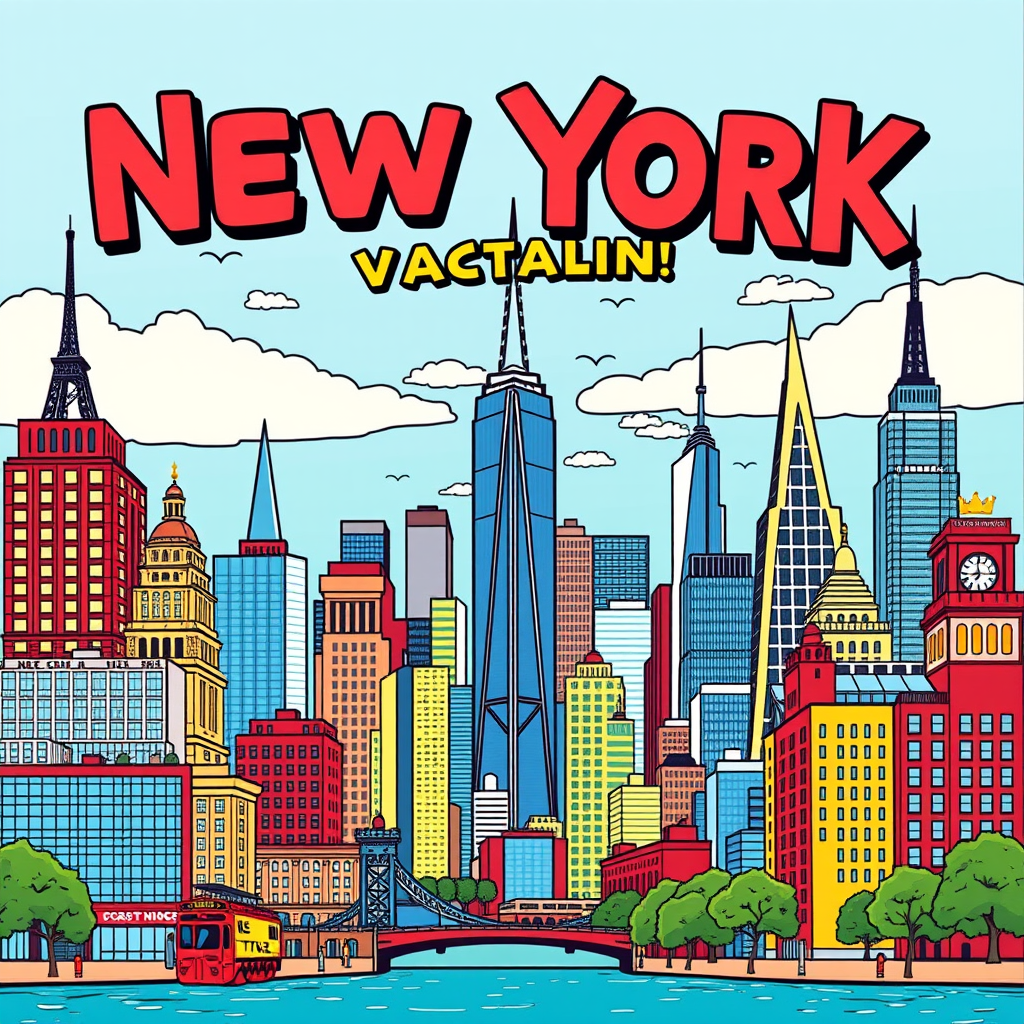

In [27]:
image = artist("New York City")
display(image)

In [42]:
def talker(message):
    try:
        # Remove 'timeout' from this specific call
        audio_bytes = client.text_to_speech(
            message, 
            model="facebook/mms-tts-eng"
        )
        
        file_path = "speech.wav"
        with open(file_path, "wb") as f:
            f.write(audio_bytes)
            
        return file_path
    except Exception as e:
        print(f"TTS Error detail: {e}")
        return None

## Let's bring this home:

1. A multi-modal AI assistant with image and audio generation
2. Tool callling with database lookup
3. A step towards an Agentic workflow


In [43]:
def chat(history):
    # 1. Clean history for the LLM
    messages_for_llm = [{"role": h["role"], "content": h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + messages_for_llm
    
    # 2. Get response from Groq (Assuming MODEL is your Groq model)
    response = groq.chat.completions.create(model=MODEL_groq, messages=messages, tools=tools)
    cities = []
    image = None

    # 3. Handle Tool Calls (Loops until the LLM stops calling functions)
    while response.choices[0].finish_reason == "tool_calls":
        message = response.choices[0].message
        tool_responses, extracted_cities = handle_tool_calls_and_return_cities(message)
        
        cities.extend(extracted_cities) # Keep track of any cities found
        messages.append(message)
        messages.extend(tool_responses)
        
        # Call back to Groq with tool results
        response = groq.chat.completions.create(model=MODEL_groq, messages=messages, tools=tools)

    # 4. Final Text Reply
    reply = response.choices[0].message.content
    history += [{"role": "assistant", "content": reply}]

    # 5. Generate Voice (Now returns a file path like "voice.mp3")
    voice = talker(reply)

    # 6. Generate Image (Using your new Hugging Face artist function)
    if cities:
        # Generates image for the first city mentioned
        image = artist(cities[0])
    
    # Gradio return: 
    # history -> gr.Chatbot, voice -> gr.Audio, image -> gr.Image
    return history, voice, image

In [44]:
def handle_tool_calls_and_return_cities(message):
    responses = []
    cities = []
    for tool_call in message.tool_calls:
        if tool_call.function.name == "get_ticket_price":
            arguments = json.loads(tool_call.function.arguments)
            city = arguments.get('destination_city')
            cities.append(city)
            price_details = get_ticket_price(city)
            responses.append({
                "role": "tool",
                "content": price_details,
                "tool_call_id": tool_call.id
            })
    return responses, cities

## The 3 types of Gradio UI

`gr.Interface` is for standard, simple UIs

`gr.ChatInterface` is for standard ChatBot UIs

`gr.Blocks` is for custom UIs where you control the components and the callbacks

In [46]:
# Callbacks (along with the chat() function above)

def put_message_in_chatbot(message, history):
        return "", history + [{"role":"user", "content":message}]

# UI definition

with gr.Blocks() as ui:
    with gr.Row():
        chatbot = gr.Chatbot(height=500, type="messages")
        image_output = gr.Image(height=500, interactive=False)
    with gr.Row():
        audio_output = gr.Audio(autoplay=True)
    with gr.Row():
        message = gr.Textbox(label="Chat with our AI Assistant:")

# Hooking up events to callbacks

    message.submit(put_message_in_chatbot, inputs=[message, chatbot], outputs=[message, chatbot]).then(
        chat, inputs=chatbot, outputs=[chatbot, audio_output, image_output]
    )

ui.launch(inbrowser=True, auth=("mime", "mime"))

* Running on local URL:  http://127.0.0.1:7868
* To create a public link, set `share=True` in `launch()`.


TTS Error detail: 
DATABASE TOOL CALLED: Getting price for London
TTS Error detail: 
DATABASE TOOL CALLED: Getting price for London
TTS Error detail: 
DATABASE TOOL CALLED: Getting price for Tokyo
DATABASE TOOL CALLED: Getting price for Tokyo
TTS Error detail: 
DATABASE TOOL CALLED: Getting price for Tokyo
DATABASE TOOL CALLED: Getting price for New York
DATABASE TOOL CALLED: Getting price for Paris
TTS Error detail: 
DATABASE TOOL CALLED: Getting price for Berlin
DATABASE TOOL CALLED: Getting price for America
TTS Error detail: 
